# 🏥 Week 4: Clinical Model Evaluation & Dashboard Integration

**Author:** Krishnaveni Mitukula 

**Phase:** Clinical Evaluation & Deployment

## Objectives:
1. **Clinical Evaluation:** Compare our trained baseline Logistic Regression and optimized Random Forest models using classification reports, confusion matrices, and ROC-AUC curves.
2. **Feature Extraction:** Extract the final Random Forest feature importances and map them to patient-facing names.
3. **Integration:** Export feature importances as a CSV file to feed our Power BI executive dashboard.

In [1]:
# Load required libraries and datasets from previous weeks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, roc_auc_score, roc_curve
warnings.filterwarnings('ignore')

# 1. Load scaled dataset
df = pd.read_csv('data/scaled_heart_disease_data.csv')

# 2. Clean data (handling string placeholders)
df = df.replace('?', np.nan)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
for col in df.columns:
    if col not in ['target', 'age_group']:
        df[col] = df[col].astype(float)

# 3. Split features and target
X = df.drop(columns=['target', 'age_group'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Datasets loaded and partitioned successfully!")

Datasets loaded and partitioned successfully!


## Train Models
We retrain the Logistic Regression baseline and the tuned Random Forest model using the optimal parameters found in Week 3.

In [2]:
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# 2. Optimized Random Forest
# Using the optimal parameters found during GridSearchCV in Week 3
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
print("Models retrained successfully!")

Models retrained successfully!


## Clinical Evaluation: Confusion Matrix & Performance Metrics
We evaluate both models, focusing on **Recall** (Sensitivity) as our primary clinical metric. In heart disease prediction, a false negative (failing to identify a sick patient) carries far worse clinical consequences than a false positive.

In [3]:
print("--- BASELINE LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Recall (Heart Disease): {recall_score(y_test, y_pred_lr):.4f}\n")

print("--- OPTIMIZED RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Recall (Heart Disease): {recall_score(y_test, y_pred_rf):.4f}")

--- BASELINE LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Confusion Matrix:
[[27  6]
 [ 2 26]]
ROC-AUC Score: 0.9535
Recall (Heart Disease): 0.9286

--- OPTIMIZED RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Confusion Matrix:
[[29  4]
 [ 2 26]]
ROC-AUC Score: 0.9589
Recall (Heart Disease): 0.9286


## ROC Curve Comparison
We plot and save the ROC curves for both models to visually compare their sensitivity and specificity trade-offs.

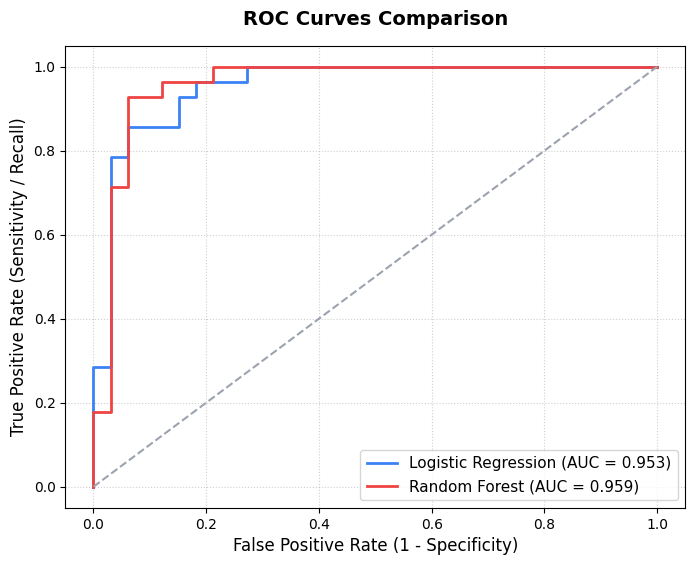

In [4]:
# Compute ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})', color='#3b82f6', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', color='#ef4444', linewidth=2)
plt.plot([0, 1], [0, 1], color='#9ca3af', linestyle='--')

plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('visualizations/model_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance Export
We extract the Random Forest feature importances and save them for our Power BI dashboard.

In [5]:
# Extract and Map Feature Importances
importances = best_rf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Map clinical columns to professional display names
column_mapping = {
    'age': 'Age',
    'sex': 'Gender',
    'cp': 'Chest Pain Type',
    'trestbps': 'Resting Blood Pressure (mmHg)',
    'chol': 'Serum Cholesterol (mg/dl)',
    'fbs': 'Fasting Blood Sugar > 120 mg/dl',
    'restecg': 'Resting ECG Results',
    'thalach': 'Max Heart Rate (bpm)',
    'exang': 'Exercise Induced Angina',
    'oldpeak': 'ST Depression',
    'slope': 'ST Slope',
    'ca': 'Major Vessels (0-3)',
    'thal': 'Thalassemia'
}
feat_imp_df['Feature'] = feat_imp_df['Feature'].map(column_mapping).fillna(feat_imp_df['Feature'])

# Save to CSV
feat_imp_df.to_csv('data/feature_importances.csv', index=False)
print("Feature importances exported successfully to 'data/feature_importances.csv'!")
print(feat_imp_df)

Feature importances exported successfully to 'data/feature_importances.csv'!
                            Feature  Importance
2                   Chest Pain Type    0.149469
12                      Thalassemia    0.138844
7              Max Heart Rate (bpm)    0.125259
11              Major Vessels (0-3)    0.114584
9                     ST Depression    0.097623
0                               Age    0.075780
4         Serum Cholesterol (mg/dl)    0.068920
3     Resting Blood Pressure (mmHg)    0.058727
8           Exercise Induced Angina    0.053675
10                         ST Slope    0.047250
1                            Gender    0.046169
6               Resting ECG Results    0.016594
5   Fasting Blood Sugar > 120 mg/dl    0.007105
